#Упражнения: Раздел 9

In [2]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows as spsig
import pandas as pd

##Упражнение 9.1


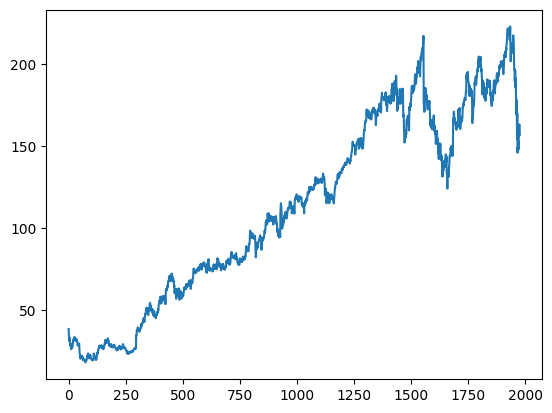

In [12]:
#Данные Facebook
if not os.path.exists('FB_2.csv'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/FB_2.csv

df = pd.read_csv('FB_2.csv', header=0, parse_dates=[0])

fb_wave = tdsp.Wave(df['Close'], framerate=1)
fb_wave.plot()

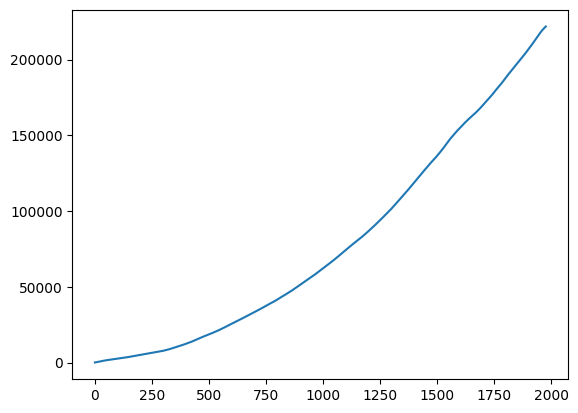

In [13]:
#Посмотрим нарастающую сумму от данных Facebook
out_wave = fb_wave.cumsum()
out_wave.unbias
out_wave.plot()

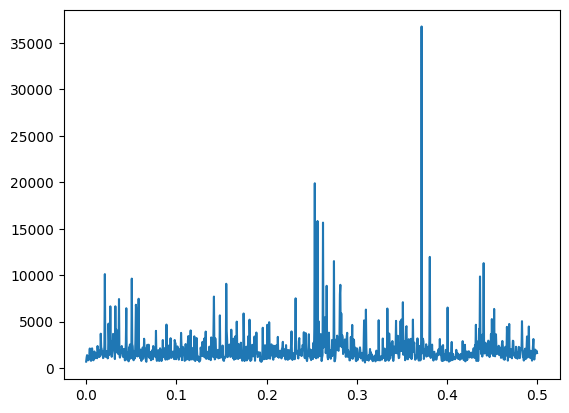

In [16]:
#сравним спектры
fb_spectrum = fb_wave.make_spectrum()
out_spectrum = out_wave.make_spectrum()
ratio_spectrum = out_spectrum.ratio(fb_spectrum, thresh=1)
ratio_spectrum.plot()

Можем заметить, что это не похоже на график фильтра интегрирования, т.е. изложенная схема не работает для апериодических сигналов.

##Упражнение 9.2
Влияние diff и differentiate на сигнал



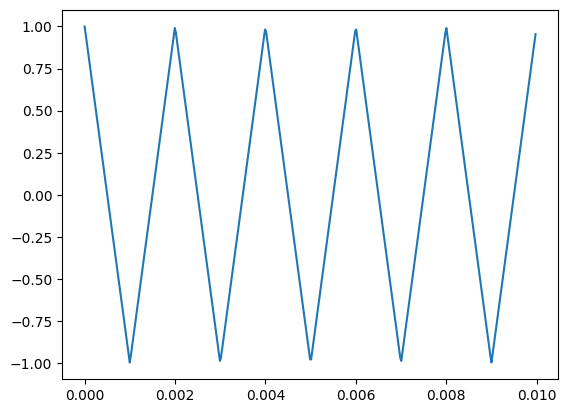

In [21]:
#создадим треугольный сигнал
in_wave = tdsp.TriangleSignal(500).make_wave(duration=0.01, framerate=44100)
in_wave.plot()

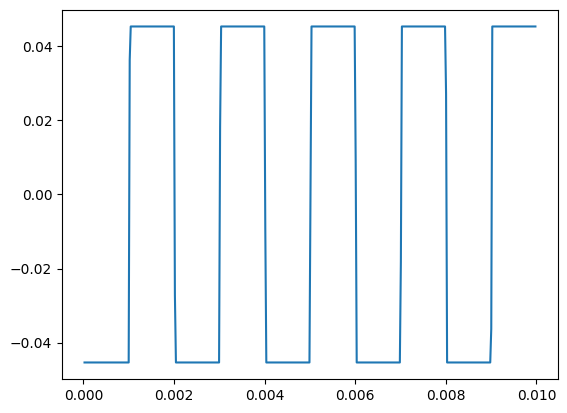

In [22]:
#применим diff к сигналу
out_wave = in_wave.diff()
out_wave.plot()

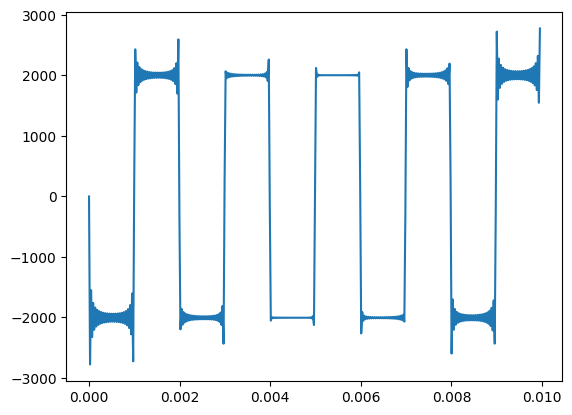

In [23]:
#применим differentiate через спектр
out_wave2 = in_wave.make_spectrum().differentiate().make_wave()
out_wave2.plot()

Получаем колебания около углов прямоугольного сигнала. Эти колебания обосновываются тем, что производная не определена на пиках треугольного сигнала.

##Упражнение 9.3
Влияние cumsum и integrate на сигнал

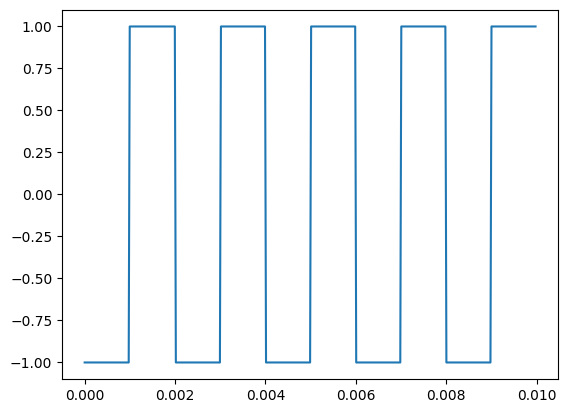

In [24]:
#создадим прямоугольный сигнал
in_wave = tdsp.SquareSignal(500).make_wave(duration=0.01, framerate=44100)
in_wave.plot()

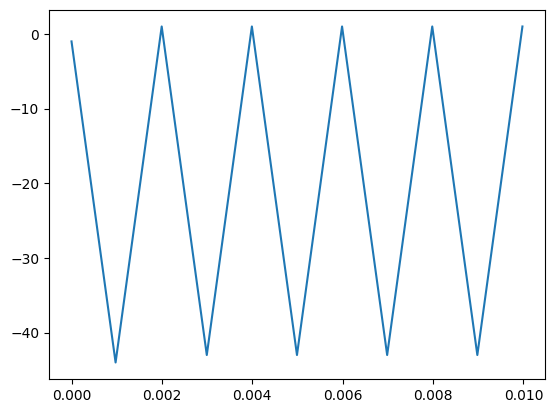

In [25]:
#применим cumsum к сигналу
out_wave = in_wave.cumsum()
out_wave.plot()

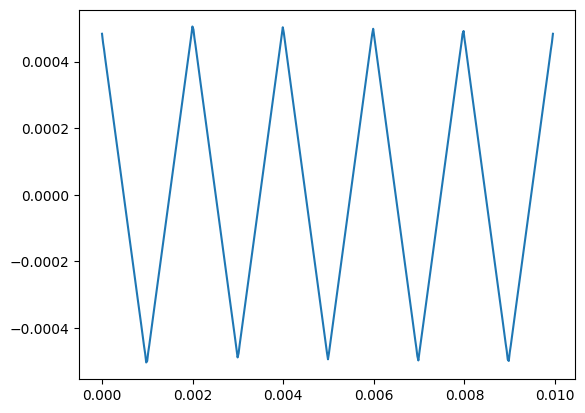

In [27]:
#применим integrate через спектр
spectrum = in_wave.make_spectrum().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()

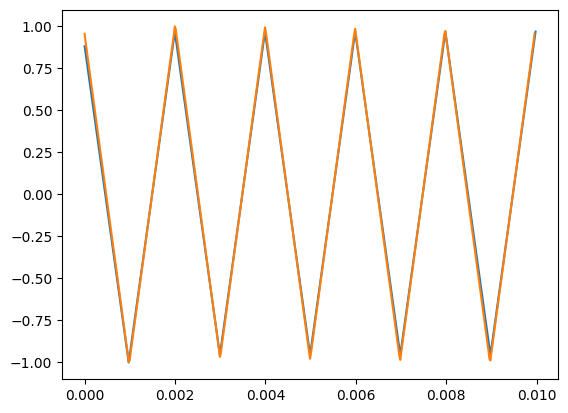

In [28]:
#приведем сигналы к единой форме
out_wave.unbias()
out_wave.normalize()
out_wave2.normalize()
out_wave.plot()
out_wave2.plot()

Визуально сигналы одинаковы

##Упражнение 9.4
Двойное интегрирование

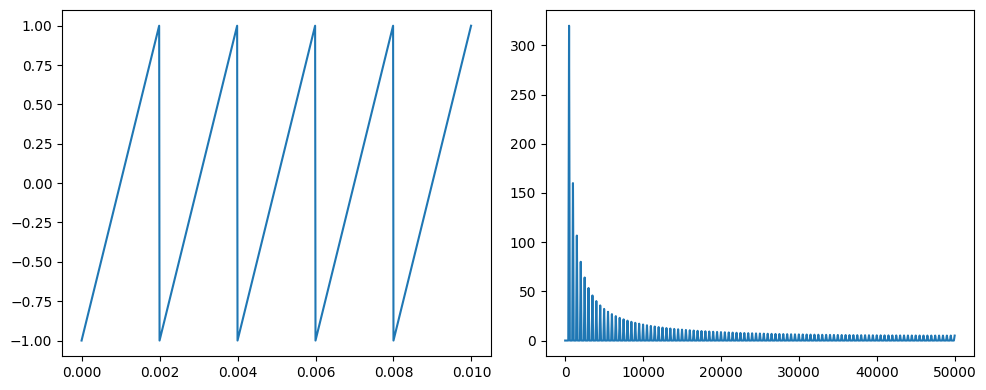

In [52]:
#создадим пилообразный сигнал
in_wave = tdsp.SawtoothSignal(500).make_wave(duration=0.01, framerate=100000)
spectrum = in_wave.make_spectrum()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
in_wave.plot()
plt.subplot(1, 2, 2)
spectrum.plot()
plt.tight_layout()
plt.show()

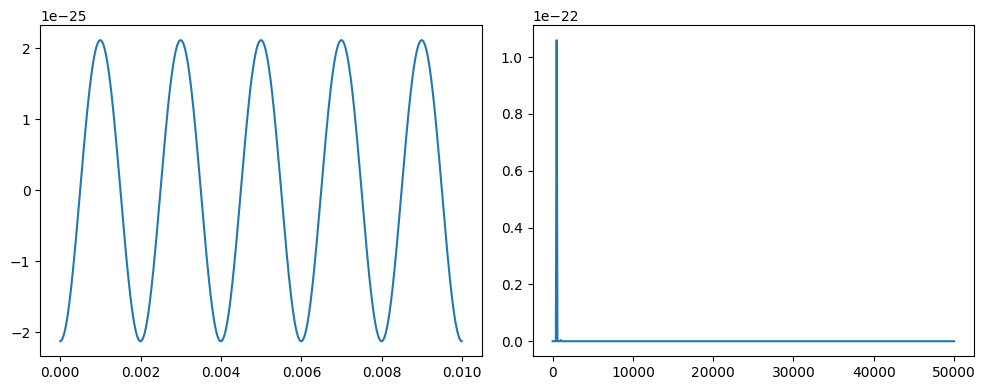

In [59]:
#применим двойное интегрирование
spectrum = spectrum.integrate().integrate()
spectrum.hs[0] = 0
out_wave = spectrum.make_wave()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
out_wave.plot()
plt.subplot(1, 2, 2)
spectrum.plot()
plt.tight_layout()
plt.show()

Можем заметить по спектрам, что интегрирование работает как фильтр НЧ. Мы убираем верхние частоты, оставляя только основную. Из-за этого сигнал на выходе больше всего похож на синусоиду. При дальнейшем интегрировании будем получать картинку, еще более похожую на синусоиду.

Двойная конечная радость и вторая производная

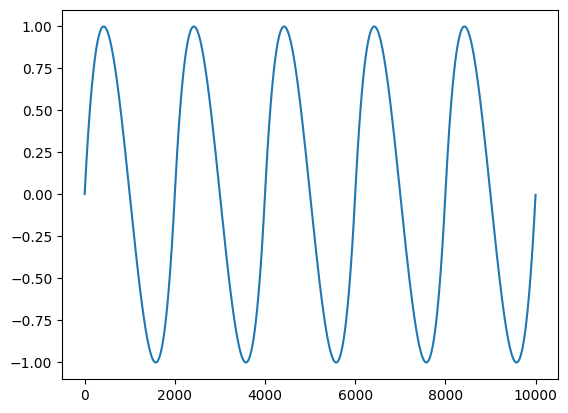

In [60]:
#создадим кубический сигнал
in_wave = tdsp.CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)
in_wave.plot()

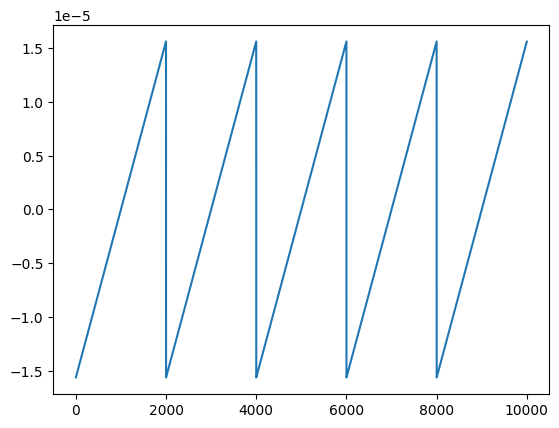

In [61]:
#применим двойную конечную разность
out_wave = in_wave.diff().diff()
out_wave.plot()

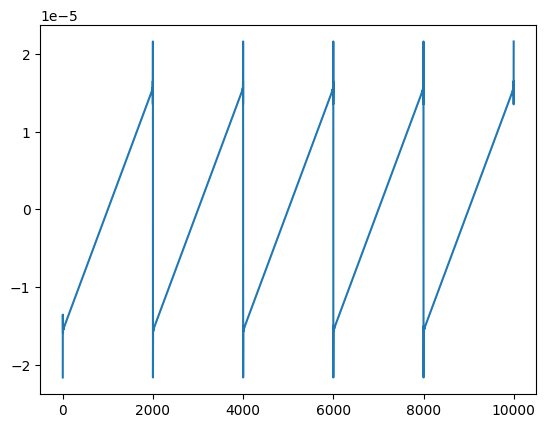

In [62]:
#получим вторую производную
spectrum = in_wave.make_spectrum().differentiate().differentiate()
out_wave2 = spectrum.make_wave()
out_wave2.plot()

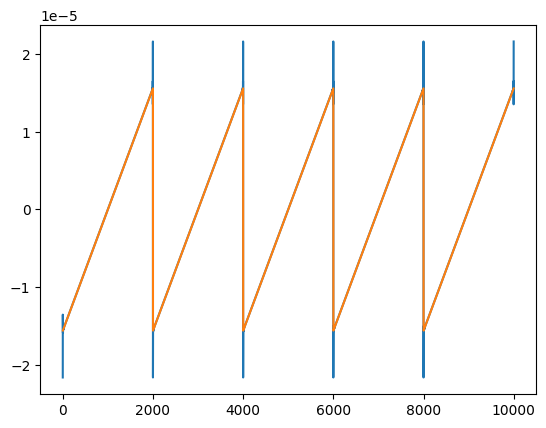

In [64]:
#наложим графики друг на друга
out_wave2.plot()
out_wave.plot()


За исключением пиков пилообраные сигналы совпадают.

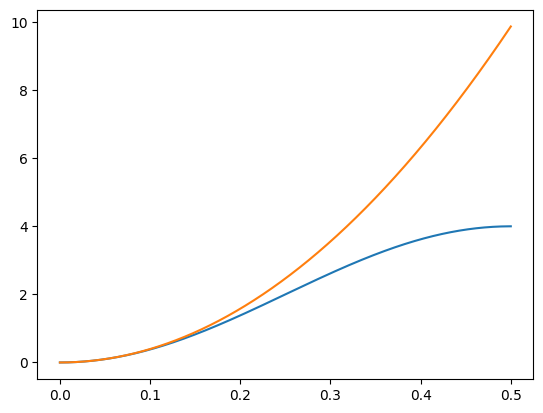

In [68]:
#получим фильтры двойных diff и differentiate
diff_window = np.array([-1.0, 2.0, -1.0])
padded = tdsp.zero_pad(diff_window, len(in_wave))
diff_wave = tdsp.Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()
diff_filter.plot()

deriv_filter = in_wave.make_spectrum()
deriv_filter.hs = (np.pi * 2 * 1j * deriv_filter.fs)**2
deriv_filter.plot()

Оба фильтра являются фильтрами ВЧ. Фильтр второй произовдной параболический, фильтр двойной конечной разницы совпадает с фильтром второй производной до 0.2, далее значительно отклоняется.